# Simulación Estadística de `apply_traffic_weights`

**Objetivos**  
- Evaluar calidad: precision, recall, f1-score sobre _n_ escenarios aleatorios.  
- Evaluar rendimiento: tiempo medio de ejecución por escenario.  
- Documentar resultados con estadísticas y visualizaciones.

**Decisiones**  
- `N_SCENARIOS`: 100  
- Métricas a calcular: precision, recall, f1, tiempo (ms)  
- Gráficos: histogramas y boxplots 


In [1]:
import time
import random
import networkx as nx
import pandas as pd
import numpy as np
from importlib.machinery import SourceFileLoader

# Carga dinámica de tu función desde su ruta
loader = SourceFileLoader("analyzer", "../traffic_events/traffic_events_analyzer.py")
analyzer = loader.load_module()
apply_traffic_weights = analyzer.apply_traffic_weights

# Parámetros de simulación 
N_SCENARIOS = 100
PENALTY_FACTOR = 1.5
PENALTY_OFFSET = 0.5
STREET_COUNT = 5          # Número de calles sintéticas
STREET_LENGTH = 10        # Tramos por calle


## 2. Generación de datos sintéticos

- **Grafo**: `STREET_COUNT` calles, cada una con `STREET_LENGTH` nodos conectados en línea.  
- **Evento**: calle aleatoria + intervalo `_start_`–`_end_` dentro de la misma calle + severidad uniforme en [0.5, 2.0].


In [2]:
def generate_synthetic_graph(num_streets, street_length):
    G = nx.Graph()
    counter = 1
    street_names = [f"Calle_{i}" for i in range(num_streets)]
    for street in street_names:
        nodes = list(range(counter, counter + street_length))
        for n in nodes:
            G.add_node(n, coord=(random.random(), random.random()))
        for u, v in zip(nodes, nodes[1:]):
            G.add_edge(u, v, weight=1.0, street_name=street)
        counter += street_length
    return G, street_names

def generate_random_event(street_names):
    street = random.choice(street_names)
    start = random.randint(1, STREET_LENGTH - 2) + (street_names.index(street)*STREET_LENGTH)
    end = random.randint(start + 1, street_names.index(street)*STREET_LENGTH + STREET_LENGTH)
    return {
        "street_name": street,
        "start_intersection": f"Inter_{start}",
        "end_intersection": f"Inter_{end}",
        "severity": round(random.uniform(0.5, 2.0), 2)
    }

## 3. Evaluación de un escenario

- Copia de grafo original  
- Medir tiempo de `apply_traffic_weights`  
- Calcular path esperado con `nx.shortest_path`  
- Comparar aristas modificadas vs. esperadas → TP, FP, FN  
- Calcular precision, recall, f1-score y tiempo (ms)

In [3]:
def evaluate_scenario(G, event, factor, offset):
    G_orig = G.copy()
    t0 = time.perf_counter()
    apply_traffic_weights(G, [event], penalty_factor=factor, penalty_offset=offset)
    t1 = time.perf_counter()
    duration_ms = (t1 - t0) * 1000

    # Extraer nodos de start/end
    s = int(event["start_intersection"].split("_")[1])
    e = int(event["end_intersection"].split("_")[1])
    path = nx.shortest_path(G_orig, source=s, target=e)
    expected = set(zip(path, path[1:]))

    # Detectar aristas modificadas
    modified = {
        (u, v) for u, v, data in G.edges(data=True)
        if abs(data["weight"] - G_orig[u][v]["weight"]) > 1e-6
    }

    tp = len(modified & expected)
    fp = len(modified - expected)
    fn = len(expected - modified)
    precision = tp/(tp+fp) if tp+fp else 1.0
    recall    = tp/(tp+fn) if tp+fn else 1.0
    f1        = 2*precision*recall/(precision+recall) if precision+recall else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "time_ms": duration_ms
    }

## 4. Simulación de N escenarios

In [4]:
results = []
for _ in range(N_SCENARIOS):
    G, streets = generate_synthetic_graph(STREET_COUNT, STREET_LENGTH)
    event = generate_random_event(streets)
    metrics = evaluate_scenario(G, event, PENALTY_FACTOR, PENALTY_OFFSET)
    metrics.update(event)
    results.append(metrics)

df = pd.DataFrame(results)
df.head(5)

,precision,recall,f1_score,time_ms,street_name,start_intersection,end_intersection,severity
0,1.0,0.0,0.0,14.927687,Calle_2,Inter_25,Inter_28,1.00
1,1.0,0.0,0.0,14.859091,Calle_4,Inter_45,Inter_49,0.52
2,1.0,0.0,0.0,13.157103,Calle_0,Inter_4,Inter_7,1.46
3,1.0,0.0,0.0,12.419147,Calle_3,Inter_35,Inter_36,0.56
4,1.0,0.0,0.0,12.006832,Calle_0,Inter_2,Inter_3,1.14


## 5. Estadística descriptiva

- `df.describe()` → media, desviación estándar, percentiles  
- Identificar outliers (valores extremos de recall o tiempo)

## Visualizaciones

- **Histogramas** de precision, recall, f1_score y time_ms  
- **Boxplots** para ver asimetrías y posibles valores atípicos

,precision,recall,f1_score,time_ms
count,100.0,100.0,100.0,100.000000
mean,1.0,0.0,0.0,12.307843
std,0.0,0.0,0.0,0.504995
min,1.0,0.0,0.0,11.524279
25%,1.0,0.0,0.0,12.042383
50%,1.0,0.0,0.0,12.262983
75%,1.0,0.0,0.0,12.489124
max,1.0,0.0,0.0,14.927687


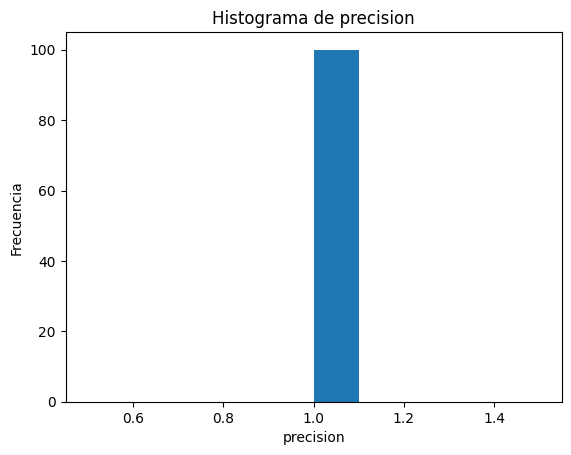

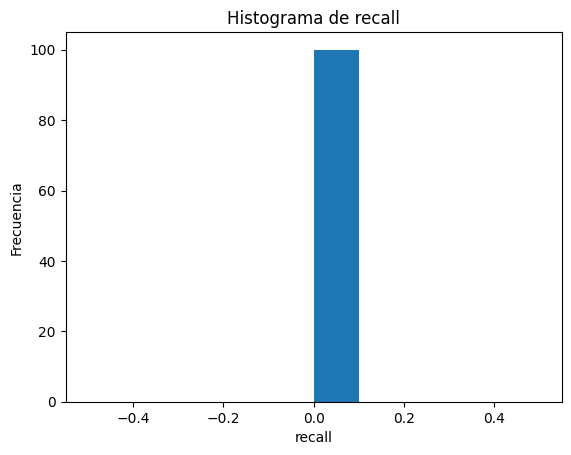

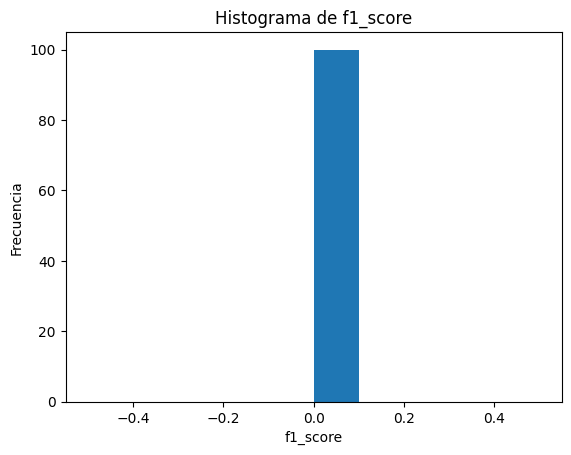

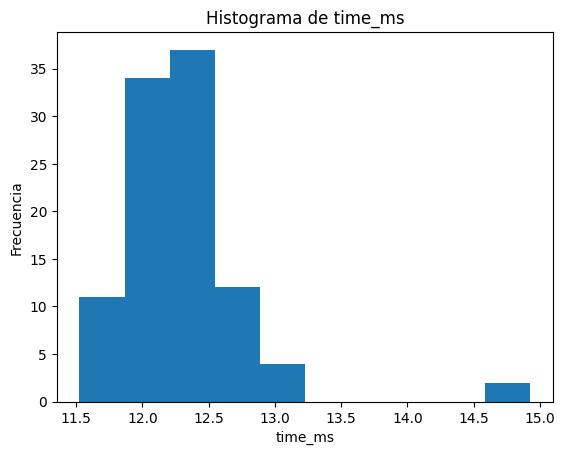

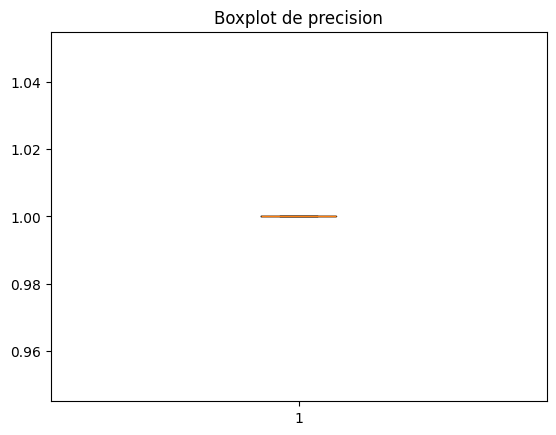

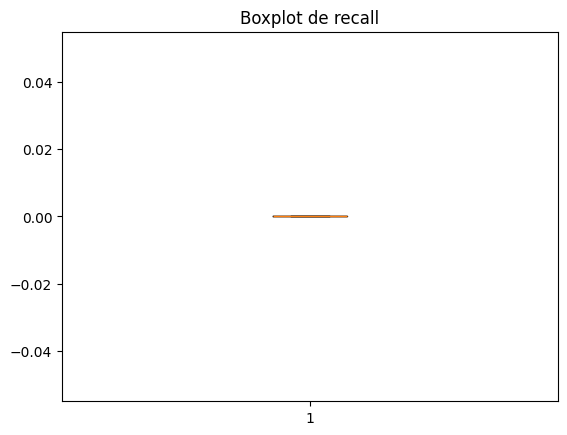

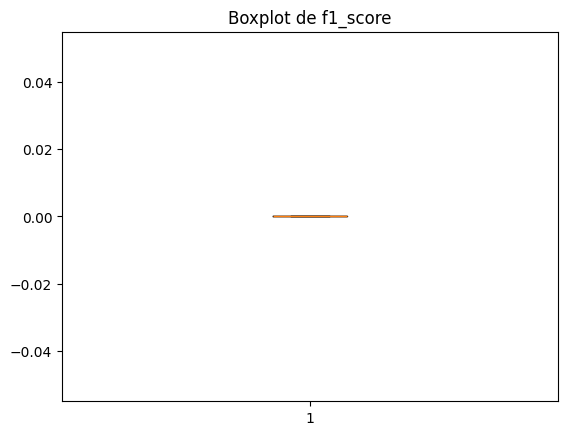

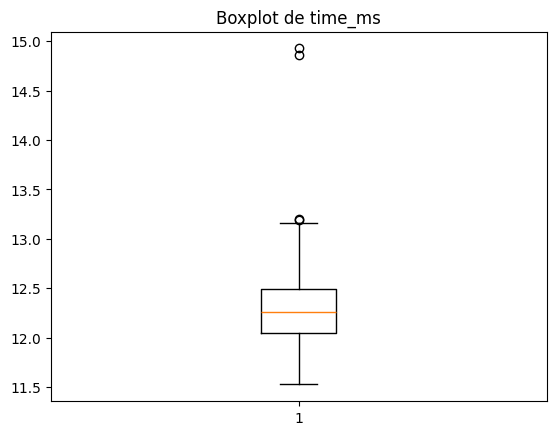

In [5]:
# Descriptivas
display(df[["precision","recall","f1_score","time_ms"]].describe())

# Histogramas
import matplotlib.pyplot as plt

for col in ["precision","recall","f1_score","time_ms"]:
    plt.figure()
    plt.hist(df[col], bins=10)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# Boxplots
for col in ["precision","recall","f1_score","time_ms"]:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [6]:
df.to_csv("/home/rc46/Escritorio/Proyects/IA_Sim_SRI/IA-Simulation-Information_Retrieval_System-Proyect/src/docs/results_simulation.csv", index=False)
print("Resultados guardados en results_simulation.csv")

Resultados guardados en results_simulation.csv
